In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,roc_auc_score,roc_curve,confusion_matrix,classification_report


In [6]:
df=sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [8]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
df.drop(['deck','who','adult_male','alive','class','embark_town','sibsp','parch'],axis=1,inplace=True)

In [10]:
df

,survived,pclass,sex,age,fare,embarked,alone
0,0,3,male,22.0,7.2500,S,False
1,1,1,female,38.0,71.2833,C,False
2,1,3,female,26.0,7.9250,S,True
3,1,1,female,35.0,53.1000,S,False
4,0,3,male,35.0,8.0500,S,True
...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S,True
887,1,1,female,19.0,30.0000,S,True
888,0,3,female,NaN,23.4500,S,False
889,1,1,male,26.0,30.0000,C,True


In [11]:
# 3 Data understanding and claeaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   fare      891 non-null    float64
 5   embarked  889 non-null    object 
 6   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(2), object(2)
memory usage: 42.8+ KB


In [12]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
alone         0
dtype: int64

Missing Value Handling
Age: Filled with median
Embarked: Filled with mode
Cabin: Dropped due to excessive missing values

In [13]:
df['age'].fillna(df['age'].median(),inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_19136\3989209341.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)


In [14]:
# 4.Encoding Categorical Variable

df=pd.get_dummies(df,columns=['sex', 'embarked','alone'],drop_first=True,dtype=int)
df

,survived,pclass,age,fare,sex_male,embarked_Q,embarked_S,alone_True
0,0,3,22.0,7.2500,1,0,1,0
1,1,1,38.0,71.2833,0,0,0,0
2,1,3,26.0,7.9250,0,0,1,1
3,1,1,35.0,53.1000,0,0,1,0
4,0,3,35.0,8.0500,1,0,1,1
...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,1,0,1,1
887,1,1,19.0,30.0000,0,0,1,1
888,0,3,28.0,23.4500,0,0,1,0
889,1,1,26.0,30.0000,1,0,0,1


5. Exploratory Data Analysis

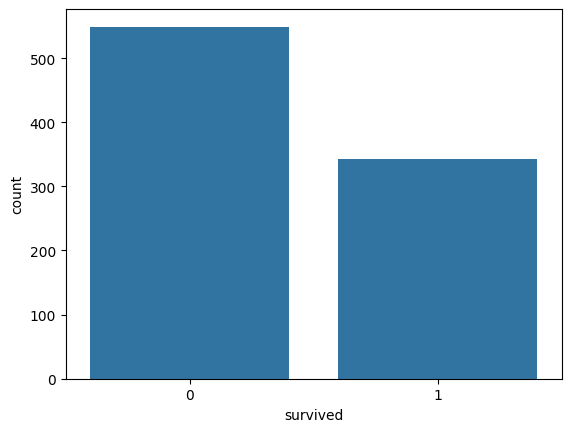

In [15]:
sns.countplot(x='survived',data=df)
plt.show()

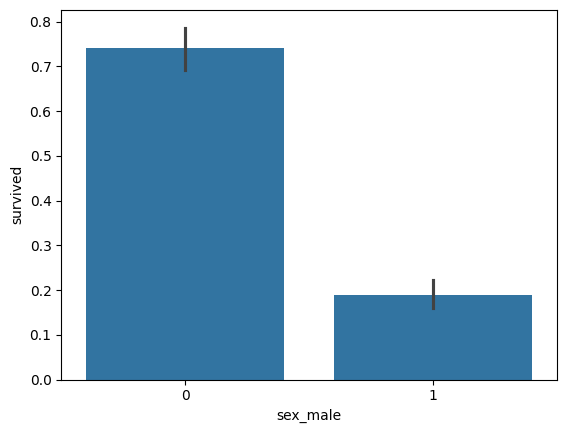

In [16]:
sns.barplot(x='sex_male',y='survived',data=df)
plt.show()

<Axes: xlabel='pclass', ylabel='survived'>

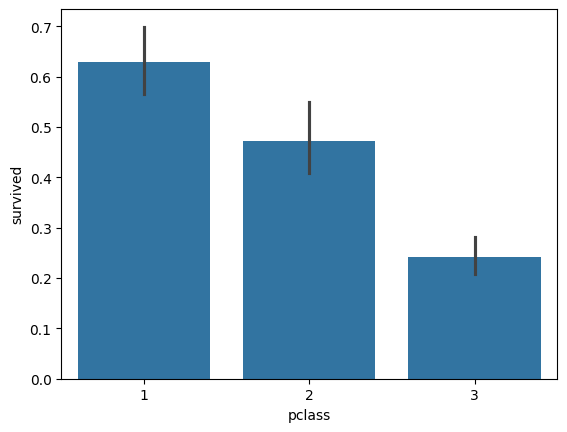

In [17]:
sns.barplot(x='pclass',y='survived',data=df)

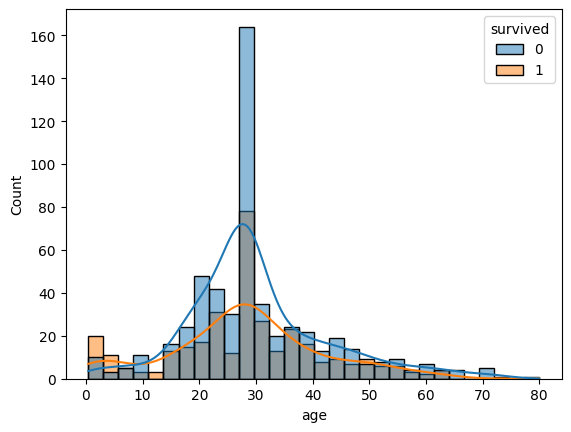

In [18]:
sns.histplot(data=df,x='age',hue='survived',bins=30,kde=True)
plt.show()

<Axes: xlabel='survived', ylabel='fare'>

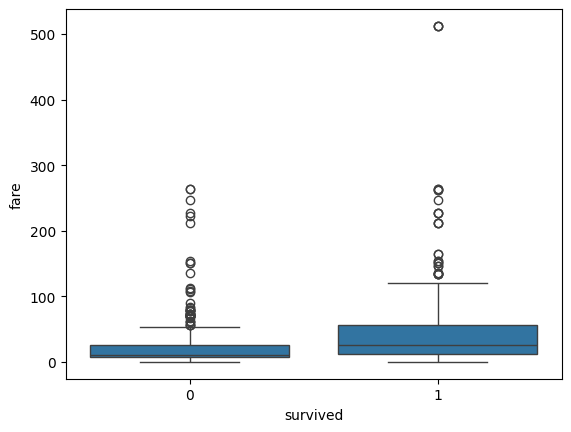

In [ ]:
sns.boxplot(data=df,x='survived',y='fare')
plt.show()

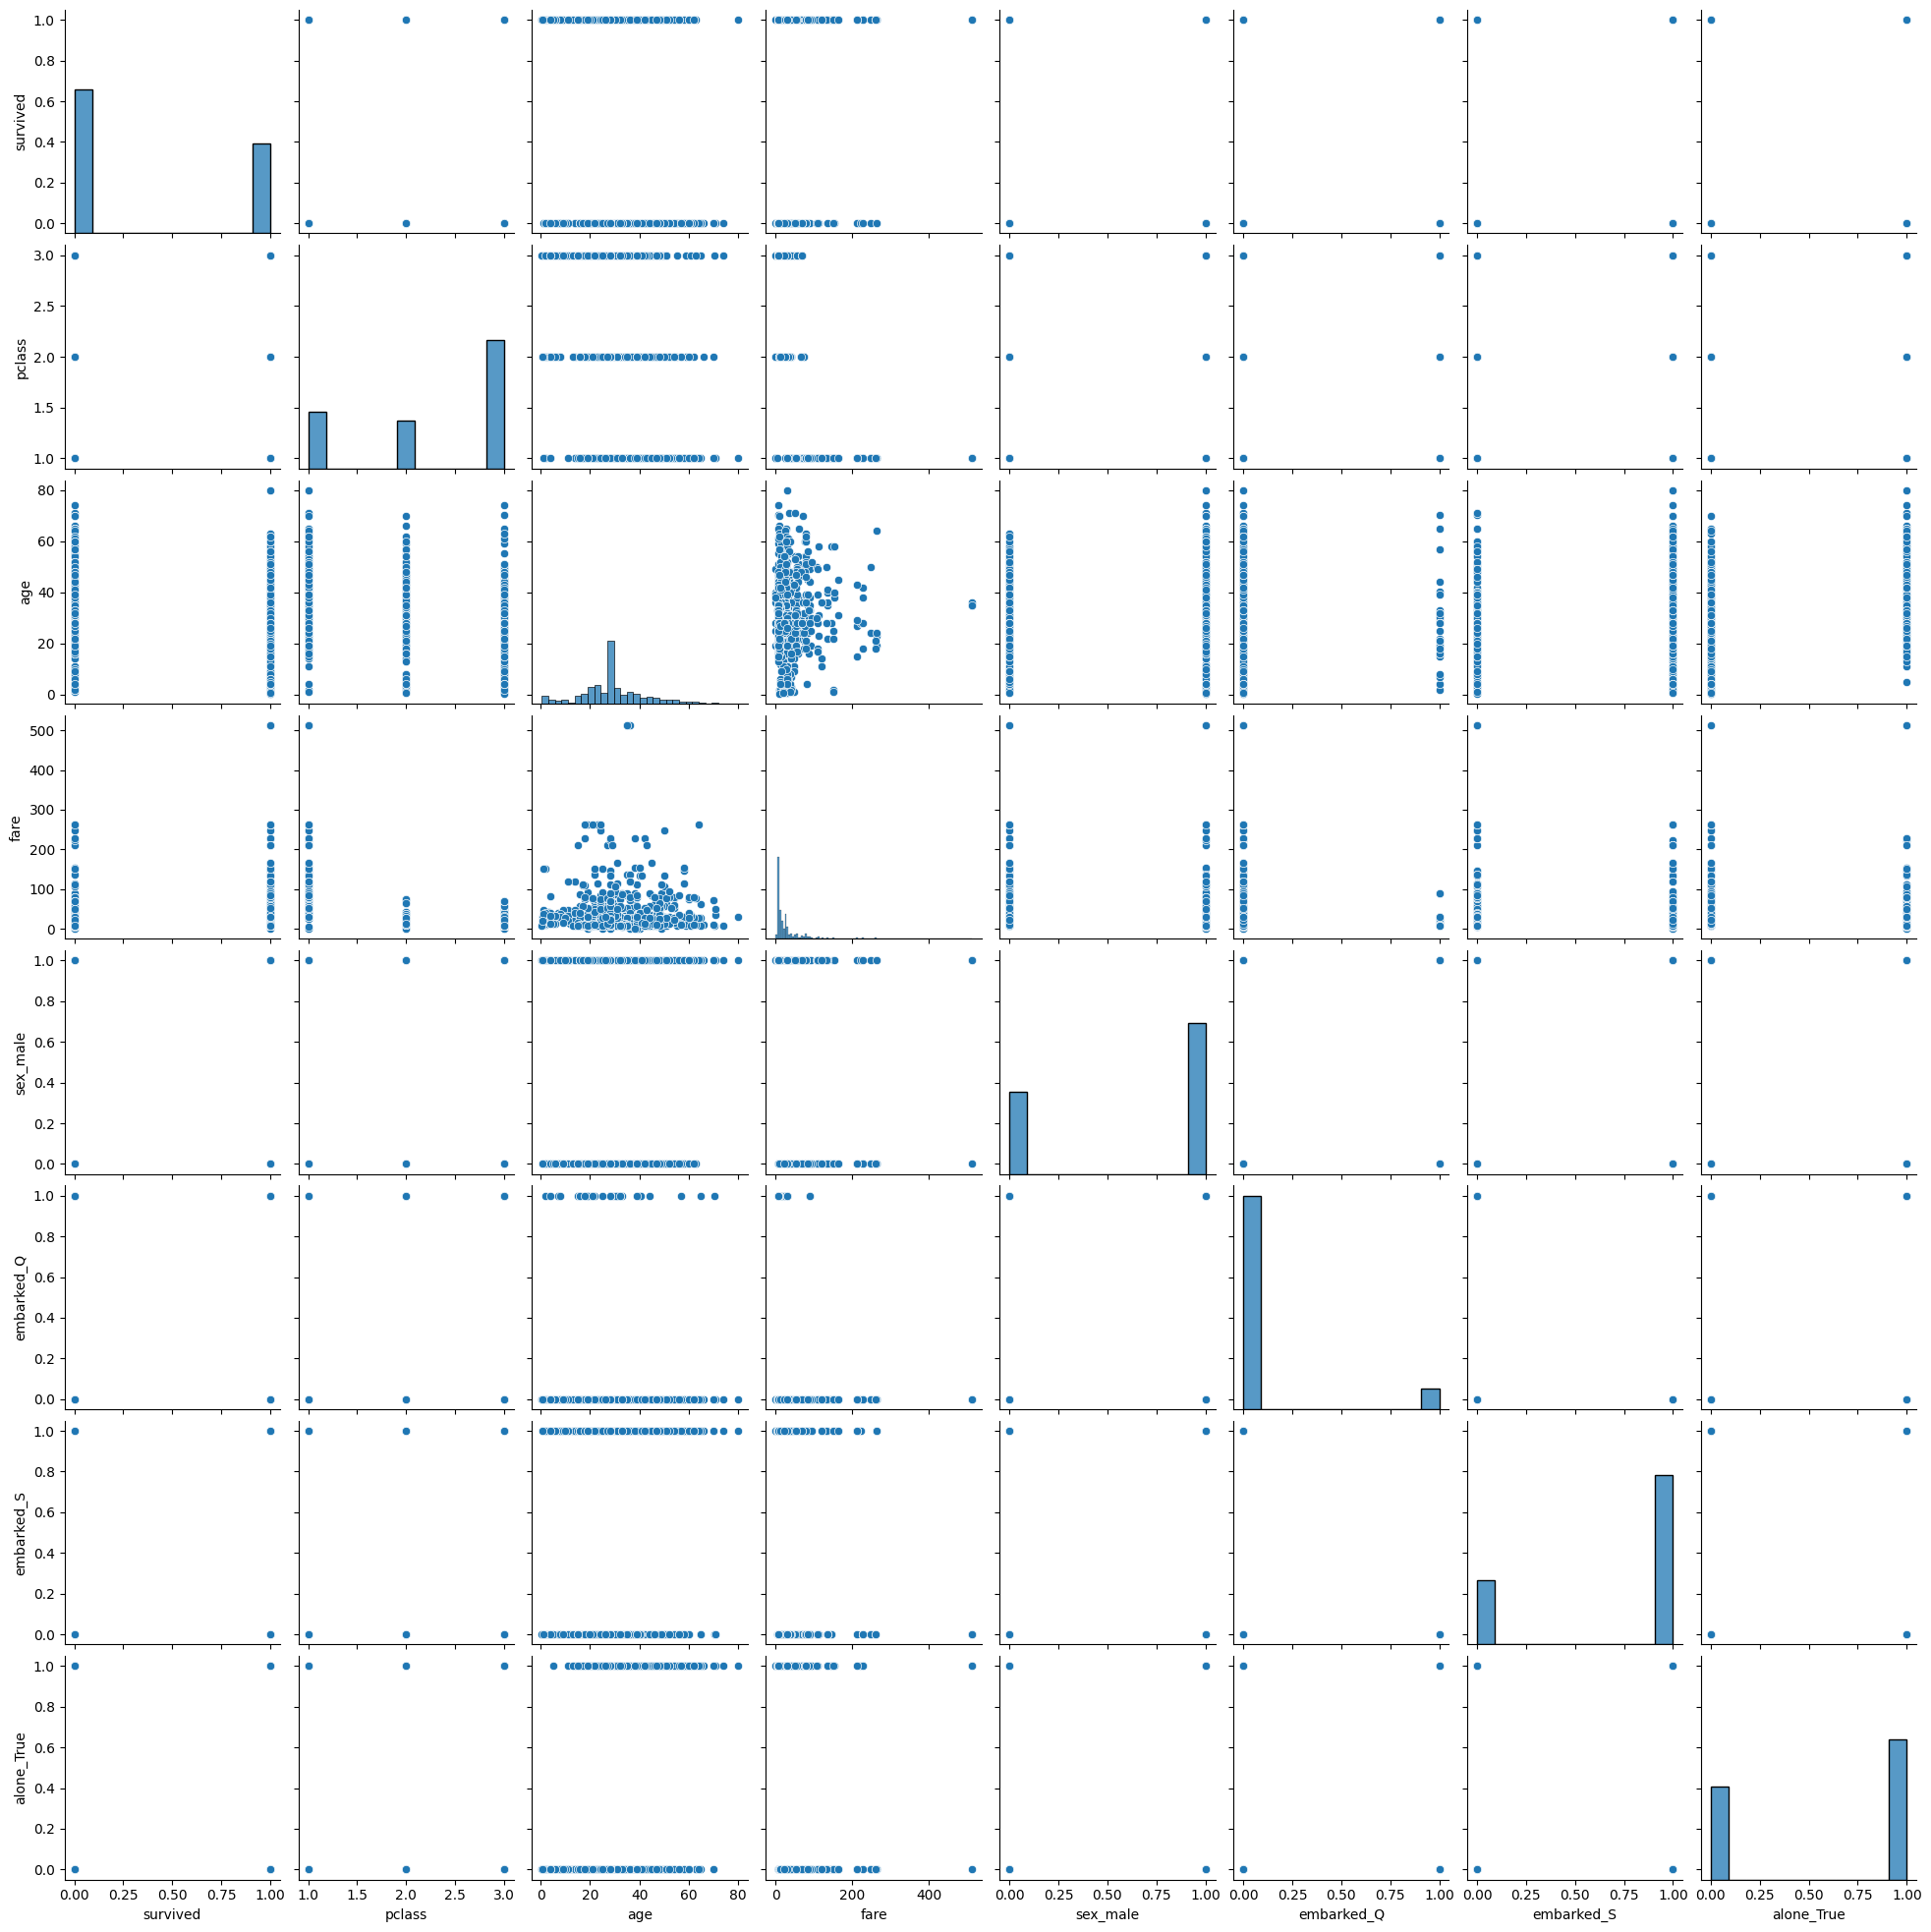

In [20]:
sns.pairplot(data=df,kind='scatter')
plt.show()

6 Feature sslection and scalling

In [21]:
x=df.iloc[:,1:]
y=df['survived']

scaler =StandardScaler()
x_scale=scaler.fit_transform(x)

In [22]:
# train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

8. Model Training - Linear & RBF SVM

In [23]:
svm_linear=SVC(kernel='linear',probability=True)
svm_rbf=SVC(kernel='rbf',probability=True)

svm_linear.fit(x_train,y_train)
svm_rbf.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [24]:
# Model Evaluation

for name,model in [('Linear SVM',svm_linear),('RBM SVM',svm_rbf)]:
    y_pred=model.predict(x_test)
    y_prob=model.predict_proba(x_test)[:,1]

    print(name)
    print("Accuracy :",accuracy_score(y_test,y_pred))
    print("ROC-AUC :",roc_auc_score(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    


Linear SVM
Accuracy : 0.7761194029850746
ROC-AUC : 0.7579876434245367
[[138  27]
 [ 33  70]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       165
           1       0.72      0.68      0.70       103

    accuracy                           0.78       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.78      0.77       268

RBM SVM
Accuracy : 0.6380597014925373
ROC-AUC : 0.5820241247425714
[[136  29]
 [ 68  35]]
              precision    recall  f1-score   support

           0       0.67      0.82      0.74       165
           1       0.55      0.34      0.42       103

    accuracy                           0.64       268
   macro avg       0.61      0.58      0.58       268
weighted avg       0.62      0.64      0.61       268



10. Hyperparameter Tuning (GridSearchCV)

In [27]:
param_grid={
    'C':[0.1,1,10],
    'gamma':[0.01,0.1,1]
}

In [28]:
grid=GridSearchCV(SVC(kernel='rbf',probability=True),param_grid,cv=5,scoring='roc_auc')

grid.fit(x_train,y_train)
best_model=grid.best_estimator_
print("Best Parameter:",grid.best_params_)

Best Parameter: {'C': 10, 'gamma': 0.01}


11. Tuned Model Evaluation

In [29]:
y_pred_best = best_model.predict(x_test)
y_prob_best = best_model.predict_proba(x_test)[:,1]

print("Tuned SVM Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned ROC-AUC:", roc_auc_score(y_test, y_prob_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned SVM Accuracy: 0.7425373134328358
Tuned ROC-AUC: 0.7659017358046485
[[128  37]
 [ 32  71]]
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       165
           1       0.66      0.69      0.67       103

    accuracy                           0.74       268
   macro avg       0.73      0.73      0.73       268
weighted avg       0.75      0.74      0.74       268

